# 二维相控阵雷达仿真 Tutorial

这个 notebook 的目标是把相控阵雷达的 mental model 和当前 `radar_basics` simulation code 对上。

我们会分两层看：

1. **一个 dwell / CPI 发生了什么**：从 look direction、发射波形、多通道 IQ，到 range-Doppler-angle processing 和 detection。
2. **一次完整 scan 发生了什么**：固定二维 beam grid 如何产生多个 dwell，多个局部观测如何合并成 detections 和 tracks。

核心 mental image：

> 一个目标在原始雷达数据中表现为：fast time 上的延迟，slow time 上的相位旋转，array space 上的相位斜率。

对应到代码就是：

```text
Scene / Truth
  -> DwellTask
  -> RawDwellData.iq: X[num_y, num_x, pulse, fast_time]
  -> range_compress()
  -> doppler_process()
  -> beamform_angle_grid()
  -> Detection
  -> Track
```


## 0. Setup

这个项目要求用 `uv` 管理和运行 Python。推荐从项目根目录运行：

```powershell
uv run jupyter notebook
```

下面的 setup cell 会自动找到项目根目录，并把 `src/` 加到 `sys.path`，这样即使 notebook 从 `learning/` 目录打开也能导入本地包。

In [1]:
%matplotlib inline

from pathlib import Path
import sys

PROJECT_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "pyproject.toml").exists() and (p / "src" / "radar_basics").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from radar_basics import (
    SPEED_OF_LIGHT,
    build_radar_system,
    build_scene,
    load_config,
    process_dwell,
    run_experiment,
    synthesize_dwell,
)
from radar_basics.display import plot_air_picture, plot_range_doppler, plot_scan_beams
from radar_basics.processing import beamform_angle_grid, doppler_process, range_compress
from radar_basics.scheduler import ScriptedScanScheduler

CONFIG_PATH = PROJECT_ROOT / "example_configs" / "architecture.yaml"

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True

def power_db(x):
    return 10.0 * np.log10(np.maximum(np.asarray(x), 1e-300))

def detection_table(detections):
    if not detections:
        return "_No detections._"
    lines = [
        "| dwell | range (m) | radial velocity (m/s) | az (deg) | el (deg) | SNR (dB) |",
        "| ---: | ---: | ---: | ---: | ---: | ---: |",
    ]
    for d in detections:
        lines.append(
            f"| {d.dwell_id} | {d.range_m:.1f} | {d.radial_velocity_mps:.2f} | "
            f"{d.az_deg:.1f} | {d.el_deg:.1f} | {d.snr_db:.1f} |"
        )
    return "\n".join(lines)

def track_table(tracks):
    if not tracks:
        return "_No tracks._"
    lines = [
        "| id | status | x (m) | y (m) | z (m) | vx (m/s) | vy (m/s) | vz (m/s) |",
        "| ---: | --- | ---: | ---: | ---: | ---: | ---: | ---: |",
    ]
    for t in tracks:
        x, y, z, vx, vy, vz = t.state_xyz_vxyz
        lines.append(f"| {t.id} | {t.status} | {x:.1f} | {y:.1f} | {z:.1f} | {vx:.2f} | {vy:.2f} | {vz:.2f} |")
    return "\n".join(lines)

PROJECT_ROOT

WindowsPath('C:/Users/yanzhang/Desktop/Research_Projects/radar_basics')

## 1. Mental model: 一个目标在数据里长什么样？

在这个仿真器里，目标不是直接变成一个 detection。目标先通过物理模型进入 raw IQ：

$$
x_{m}[p,t]
\approx
\alpha\,B_t(u;u_l)\,a_m(u)\,s(t-\tau)\,e^{j2\pi (f_D \cdot p \cdot T_{\mathrm{PRI}})}
$$

下图把这条公式映射回物理世界：目标方向 $u$、look direction $u_l$、阵元位置 $r_m$、入射平面波，以及 range / Doppler / array response 如何共同决定 raw IQ。

<img src="../assets/imgs/2D_phased_array_worldview.png" alt="二维相控阵雷达 physical world model" width="100%">

> 注意：图中的 azimuth angle 和 elevation angle 标记位置不准确；这里主要用它帮助建立物理量之间的对应关系。


### 1.1 变量含义和数学类型

| Symbol | Mathematical Type | Physical meaning |
| --- | --- | --- |
| $x_m[p,t]$ | $\in \mathbb{C}$ | 第 $m$ 个接收通道、在第 $p$ 个 pulse、fast time $t$ 上采到的 complex IQ sample。 |
| $\alpha$ | $\in \mathbb{C}$ | 目标复幅度，概括 RCS、传播损耗、传播相位等效果。 |
| $B_t(u;u_l)$ | $\in \mathbb{R}_{\ge 0}$ | 发射波束 steered 到 $u_l$ 时，在目标方向 $u$ 上的 normalized transmit field gain magnitude。 |
| $a_m(u)$ | $\in \mathbb{C}$ | 方向 $u$ 的来波在第 $m$ 个阵元上的 steering-vector element。 |
| $a(u)$ | $\in \mathbb{C}^{M}$ | 全阵列 steering vector，$a(u)=[a_1(u),\dots,a_M(u)]^T$。 |
| $s(t-\tau)$ | $\in \mathbb{C}$ | 被 round-trip delay $\tau$ 延迟后的 transmitted waveform sample。 |
| $e^{j2\pi(f_D\cdot p\cdot T_{\mathrm{PRI}})}$ | $\in \mathbb{C}$ | slow time 上的 pulse-to-pulse phase rotation。 |
| $f_D$ | $\in \mathbb{R}$ | Doppler frequency。 |
| $T_{\mathrm{PRI}}$ | $\in \mathbb{R}_{>0}$ | pulse repetition interval。 |
| $\tau$ | $\in \mathbb{R}_{\ge 0}$ | round-trip delay，$\tau=2R/c$。 |
| $u$ | $\in \mathbb{R}^3,\ \|u\|=1$ | 从雷达到目标的 unit direction vector；外部通常用 azimuth/elevation 表示。 |
| $u_l$ | $\in \mathbb{R}^3,\ \|u_l\|=1$ | 当前 dwell 的 look / steering direction。 |
| $r_m$ | $\in \mathbb{R}^3$ | 第 $m$ 个阵元在雷达坐标系中的位置向量。 |
| $\lambda$ | $\in \mathbb{R}_{>0}$ | carrier wavelength。 |
| $R$ | $\in \mathbb{R}_{>0}$ | 目标距离。 |
| $v_r$ | $\in \mathbb{R}$ | 目标径向速度。 |
| $\mathbf{x}$ | $\in \mathbb{R}^3$ | 目标位置向量。 |
| $\mathbf{v}$ | $\in \mathbb{R}^3$ | 目标速度向量。 |

### 1.2 下标和索引含义

| Index / subscript | Mathematical Type | Meaning |
| --- | --- | --- |
| $m$ | $\in \{1,\dots,M\}$ | array element / receive channel index。公式中的 $x_m$、$a_m$、$r_m$ 都是“第 $m$ 个阵元”的量。 |
| $p$ | $\in \{0,\dots,P-1\}$ | pulse index，也就是 slow-time index。注意这里 $p$ 不是位置向量。 |
| $t$ | $\in \mathbb{R}$ | fast-time variable，表示单个 PRI 内的采样时间。离散实现里对应 fast-time sample index。 |
| $l$ | dwell / look index | $u_l$ 里的 $l$ 表示第 $l$ 个 dwell 的 look direction。 |
| $M$ | $\in \mathbb{Z}_{>0}$ | 阵元总数。 |
| $P$ | $\in \mathbb{Z}_{>0}$ | 一个 dwell / CPI 内的 pulse 总数。 |

第 $p$ 个 pulse 的 slow-time 时刻是：

$$
t_p=p\cdot T_{\mathrm{PRI}}
$$

所以 Doppler 相位是：

$$
2\pi f_D t_p = 2\pi(f_D\cdot p\cdot T_{\mathrm{PRI}})
$$

### 1.3 几个关键项的具体定义

方向 $u$ 外部常写成 angle pair：

$$
u=(\theta,\phi)=(\text{azimuth},\text{elevation})
$$

在代码里会转成三维单位方向向量：

$$
u(\theta,\phi)=\begin{bmatrix}\cos\phi\cos\theta & \cos\phi\sin\theta & \sin\phi\end{bmatrix}^T
$$

当前代码采用的 narrowband steering-vector element 是：

$$
a_m(u)=\exp\left(j\frac{2\pi}{\lambda}r_m^T u\right)
$$

有些教材会写成负号版本 $\exp(-j\frac{2\pi}{\lambda}r_m^T u)$；这是相位参考和接收/发射约定不同，物理意义仍然是“方向 $u$ 在阵列上形成的空间相位斜率”。

当前代码使用的 normalized transmit field gain magnitude 是：

$$
B_t(u;u_l)=\left|\frac{1}{M}\sum_{m=1}^{M}\exp\left(j\frac{2\pi}{\lambda}r_m^T(u-u_l)\right)\right|
$$

目标方向 $u$ 越接近 look direction $u_l$，阵元发射相位越能相干叠加，$B_t$ 越大。

Doppler frequency 和 radial velocity 的大小关系是：

$$
f_D=\frac{2v_r}{\lambda}
$$

其中 radial velocity 可写成：

$$
v_r=\mathbf{v}^T\frac{\mathbf{x}}{\|\mathbf{x}\|}
$$

当前仿真代码把传播相位写成 $\exp(-j4\pi R/\lambda)$，因此 slow-time 中实际观察到的基带频率符号是 $f_{slow}=-2v_r/\lambda$；`doppler_process()` 再用 $v_r=-f_{slow}\lambda/2$ 转回径向速度。

所以 processing 的本质是：

```text
fast time matched filtering -> range
slow time FFT              -> Doppler / radial velocity
array steering projection  -> angle
```

## 2. Load config: 建立 radar、scene 和 scan schedule

我们先读取 `example_configs/architecture.yaml`。这个配置定义了：

- radar carrier / power / noise；
- 4 x 4 rectangular planar array；
- LFM pulse waveform；
- 一个固定二维 scan grid；
- 一个点目标；
- processing angle grid、detector、tracker。

In [2]:
config = load_config(CONFIG_PATH)
radar = build_radar_system(config)
scene = build_scene(config)

scheduler = ScriptedScanScheduler(
    azimuths_deg=config.scan.azimuths_deg,
    elevations_deg=config.scan.elevations_deg,
    prf_hz=radar.waveform.prf_hz,
    num_pulses=radar.waveform.num_pulses,
    mode=config.scan.mode,
)
tasks = scheduler.tasks(num_scan_cycles=config.run.num_scan_cycles)

print(f"config: {CONFIG_PATH.relative_to(PROJECT_ROOT)}")
print(f"carrier frequency: {radar.carrier_frequency_hz/1e9:.2f} GHz")
print(f"wavelength: {radar.wavelength_m:.4f} m")
print(f"array: {radar.array.num_y} x {radar.array.num_x} elements")
print(f"array spacing: y={radar.array.spacing_y_m:.4f} m, x={radar.array.spacing_x_m:.4f} m")
print(f"bandwidth: {radar.waveform.bandwidth_hz/1e6:.1f} MHz")
print(f"range resolution: {radar.range_resolution_m:.2f} m")
print(f"PRF: {radar.waveform.prf_hz:.1f} Hz")
print(f"num pulses per dwell: {radar.waveform.num_pulses}")
print(f"velocity resolution: {radar.velocity_resolution_mps:.2f} m/s")
print(f"num dwell tasks: {len(tasks)}")

for snapshot in scene.snapshots_at(0.0):
    print(
        f"target {snapshot.name}: range={snapshot.range_m:.1f} m, "
        f"az={snapshot.az_deg:.1f} deg, el={snapshot.el_deg:.1f} deg, "
        f"vr={snapshot.radial_velocity_mps:.1f} m/s, rcs={snapshot.rcs_m2:.1f} m^2"
    )

config: example_configs\architecture.yaml
carrier frequency: 10.00 GHz
wavelength: 0.0300 m
array: 4 x 4 elements
array spacing: y=0.0150 m, x=0.0150 m
bandwidth: 5.0 MHz
range resolution: 29.98 m
PRF: 10000.0 Hz
num pulses per dwell: 16
velocity resolution: 9.37 m/s
num dwell tasks: 18
target target-a: range=1500.0 m, az=0.0 deg, el=0.0 deg, vr=0.0 m/s, rcs=10.0 m^2


### 2.1 Object Map: 这些对象各自代表什么？

这几个名字很容易混在一起，因为它们都来自同一份 YAML。但它们在 simulation pipeline 里扮演的是不同角色：

```text
architecture.yaml
  -> config                 # immutable experiment specification
  -> radar + scene          # simulation objects: hardware + truth world
  -> scheduler -> tasks     # execution plan: when to point where
  -> synthesize_dwell(radar, scene, task, rng)
```

| Object | Python type | Radar concept | Owns what data | Key methods / properties | Downstream consumer |
| --- | --- | --- | --- | --- | --- |
| `config` | `ExperimentConfig` | experiment specification | YAML sections after validation: `radar`, `array`, `waveform`, `scan`, `scene`, `processing`, `run` | dataclass fields only; no physics behavior | builder functions, `run_experiment()` |
| `radar` | `RadarSystem` | radar hardware + waveform model | carrier, peak power, array, waveform, noise figure, loss, temperature | `wavelength_m`, `range_resolution_m`, `velocity_resolution_mps`, `max_unambiguous_range_m`, `noise_power_w` | `synthesize_dwell()`, `process_dwell()` |
| `radar.array` | `RectangularArray` | planar phased array aperture | element counts, element spacings | `positions_m`, `num_elements`, `steering_vector()`, `transmit_field_gain()` | echo synthesis, beamforming |
| `radar.waveform` | `LfmPulseWaveform` | coherent LFM pulse train | bandwidth, pulse width, PRF, pulse count, sample rate | `pri_s`, `chirp_slope_hz_per_s`, `fast_time_axis_s()`, `pulse_time_axis_s()`, `samples()` | echo synthesis, matched filtering, Doppler processing |
| `scene` | `Scene` | truth world | tuple of `PointTarget` objects | `snapshots_at(time_s)` | `synthesize_dwell()` |
| `scheduler` | `ScriptedScanScheduler` | fixed scan policy | azimuth grid, elevation grid, PRF, pulse count, mode | `tasks(num_scan_cycles, start_time_s)` | produces `DwellTask` objects |
| `tasks` | `tuple[DwellTask, ...]` | dwell / CPI execution schedule | one item per beam look: id, mode, look angle, start time, PRF, pulse count | each task has `pri_s`, `duration_s`, `center_time_s` | one `DwellTask` per `synthesize_dwell()` call |

Mental split:

- `config` 是 **specification**：它描述想要的 experiment，不直接产生 IQ。
- `radar` 和 `scene` 是 **simulation objects**：一个描述雷达怎么发射/接收，一个描述世界里有什么目标。
- `scheduler` 和 `tasks` 是 **execution plan**：它们决定 radar 在什么时间、朝哪个方向做一次 dwell。


### 2.2 Method descriptions: 从 YAML 到可仿真的对象

这一段 notebook 里的构造顺序对应下面几层 API：

- `load_config(path)`：读取 YAML，调用 parser，返回 `ExperimentConfig`。它会检查未知 key、缺失字段、类型错误、非正数等问题。
- `build_radar_system(config)`：读取 `config.radar`、`config.array`、`config.waveform`，构造 `RadarSystem`。如果 array spacing 没写，默认用 half wavelength。
- `build_scene(config)`：读取 `config.scene.targets`，构造 `Scene(PointTarget, ...)`。YAML 可以用 spherical target fields，例如 `range_m`、`az_deg`、`el_deg`、`radial_velocity_mps`；parser 会把它们转成 Cartesian position / velocity。
- `ScriptedScanScheduler(...)`：保存 fixed scan grid 和 dwell waveform timing，不运行仿真。
- `scheduler.tasks(...)`：把 scan grid 展开成按时间排序的 `DwellTask` tuple。当前实现是 elevation-major order：先固定一个 elevation，扫完所有 azimuth，再进入下一个 elevation。

这些 API 故意分层：你可以单独 inspect config，也可以手工创建 radar/scene/task 来做一个最小仿真，或者让 `run_experiment(CONFIG_PATH)` 自动串起来。


In [ ]:
from dataclasses import fields

print(type(config).__name__)
print("top-level config sections:", [field.name for field in fields(config)])
print()

print("scan specification")
print("  azimuths_deg:", config.scan.azimuths_deg)
print("  elevations_deg:", config.scan.elevations_deg)
print("  mode:", config.scan.mode)
print()

print("processing specification")
print("  angle_grid_az_deg:", config.processing.angle_grid_az_deg)
print("  angle_grid_el_deg:", config.processing.angle_grid_el_deg)
print("  detector:", config.processing.detector)
print("  tracker:", config.processing.tracker)
print()

print("run specification")
print("  num_scan_cycles:", config.run.num_scan_cycles)
print("  seed:", config.run.seed)
print("  store_raw:", config.run.store_raw)


### 2.3 `config`: immutable experiment specification

`config` 的 mental model 是：**validated YAML as Python dataclasses**。

它不表示一个正在运行的 radar，也不保存 raw IQ。它只是把 YAML 中的 experiment intent 固定下来，并给后续 builder functions 使用。

常用访问方式就是 `config.<section>.<field>`：

```python
config.radar.carrier_frequency_hz
config.array.num_y
config.waveform.num_pulses
config.scan.azimuths_deg
config.processing.detector.threshold_snr_db
config.run.num_scan_cycles
```

如果你想改 experiment，通常改 YAML，然后重新 `load_config()`；或者在 Python 里构造新的 dataclass config。


### 2.4 `radar`: hardware + waveform behavior

`radar` 是 `RadarSystem`。它把雷达硬件参数、阵列、波形和噪声模型放在一起。

主要 derived properties：

| Property | Meaning |
| --- | --- |
| `wavelength_m` | carrier frequency 对应的 wavelength。阵元默认间距会用它的一半。 |
| `max_unambiguous_range_m` | 由 PRF/PRI 决定的最大不模糊距离，$c \cdot PRI / 2$。 |
| `range_resolution_m` | 由 bandwidth 决定的距离分辨率，$c / (2B)$。 |
| `velocity_resolution_mps` | 由 wavelength 和 coherent processing interval 决定的 Doppler/velocity bin spacing。 |
| `max_unambiguous_velocity_mps` | 由 wavelength 和 PRF 决定的最大不模糊径向速度。 |
| `noise_power_w` | thermal noise power，来自 temperature、noise figure、sample rate。 |

它的两个关键子对象是：

- `radar.array`: `RectangularArray`，负责 element positions、steering vector、transmit field gain。
- `radar.waveform`: `LfmPulseWaveform`，负责 PRI、LFM chirp slope、fast-time axis、pulse-time axis、baseband chirp samples。


In [ ]:
print(type(radar).__name__)
print(f"carrier_frequency_hz = {radar.carrier_frequency_hz:.3e}")
print(f"wavelength_m = {radar.wavelength_m:.6f}")
print(f"max_unambiguous_range_m = {radar.max_unambiguous_range_m:.1f}")
print(f"range_resolution_m = {radar.range_resolution_m:.2f}")
print(f"velocity_resolution_mps = {radar.velocity_resolution_mps:.2f}")
print(f"max_unambiguous_velocity_mps = {radar.max_unambiguous_velocity_mps:.2f}")
print(f"noise_power_w = {radar.noise_power_w:.3e}")
print()

print("array")
print(f"  type = {type(radar.array).__name__}")
print(f"  num_elements = {radar.array.num_elements}")
print(f"  positions_m.shape = {radar.array.positions_m.shape}")
print(f"  first element position = {radar.array.positions_m[0, 0]}")
print(f"  last element position = {radar.array.positions_m[-1, -1]}")
print()

print("waveform")
print(f"  type = {type(radar.waveform).__name__}")
print(f"  pri_s = {radar.waveform.pri_s:.6e}")
print(f"  chirp_slope_hz_per_s = {radar.waveform.chirp_slope_hz_per_s:.3e}")
print(f"  num_fast_time_samples = {radar.waveform.num_fast_time_samples}")
print(f"  num_pulse_samples = {radar.waveform.num_pulse_samples}")
print(f"  samples().shape = {radar.waveform.samples().shape}")


### 2.5 `RectangularArray`: angle lives as spatial phase

`RectangularArray.steering_vector(wavelength_m, az_deg, el_deg)` 返回一个 shape 为 `(num_y, num_x)` 的 complex array。它描述：如果一个 plane wave 从某个 az/el 方向来，每个阵元会看到什么相位。

`RectangularArray.transmit_field_gain(wavelength_m, look_az_deg, look_el_deg, target_az_deg, target_el_deg)` 返回一个 normalized field gain magnitude：当 beam 指向 look direction 时，target direction 得到多强的照射。目标方向越接近 look direction，通常 gain 越大。

这两个 method 是 phased-array mental model 的核心：

- receive angle: target direction -> array phase pattern -> `steering_vector()`
- transmit pointing: look direction vs target direction -> illumination strength -> `transmit_field_gain()`


In [ ]:
boresight = radar.array.steering_vector(radar.wavelength_m, az_deg=0.0, el_deg=0.0)
off_boresight = radar.array.steering_vector(radar.wavelength_m, az_deg=10.0, el_deg=5.0)

print("steering vector shapes")
print("  boresight:", boresight.shape)
print("  off_boresight:", off_boresight.shape)
print()

print("boresight phase pattern, radians")
print(np.round(np.angle(boresight), 3))
print()

print("off-boresight phase pattern, radians")
print(np.round(np.angle(off_boresight), 3))
print()

for target_az in [-10.0, 0.0, 10.0, 20.0]:
    gain = radar.array.transmit_field_gain(
        radar.wavelength_m,
        look_az_deg=0.0,
        look_el_deg=0.0,
        target_az_deg=target_az,
        target_el_deg=0.0,
    )
    print(f"look az=0 deg, target az={target_az:>5.1f} deg -> transmit field gain={gain:.3f}")


### 2.6 `scene`: truth world, not measurements

`scene` 是 `Scene`，里面保存 `PointTarget` objects。它代表仿真世界里的 ground truth。

主要 API：

- `PointTarget.position_at(time_s)`：目标在某个时间的 Cartesian position。
- `PointTarget.velocity_at(time_s)`：目标在某个时间的 Cartesian velocity。当前 v1 是 constant velocity。
- `PointTarget.snapshot_at(time_s)`：把 position/velocity 转成 radar-friendly truth fields，例如 range、azimuth、elevation、radial velocity、RCS。
- `Scene.snapshots_at(time_s)`：对 scene 中所有 targets 调用 `snapshot_at()`。

注意：snapshot 是 truth，不是 detection。Detection 是后面 raw IQ 经过 range compression、Doppler processing、beamforming 和 detector 后产生的 noisy/quantized observation。


In [ ]:
for time_s in [0.0, tasks[0].center_time_s, tasks[-1].center_time_s]:
    print(f"time_s = {time_s:.6f}")
    for snapshot in scene.snapshots_at(time_s):
        print(
            f"  {snapshot.name}: "
            f"range={snapshot.range_m:.2f} m, "
            f"az={snapshot.az_deg:.2f} deg, "
            f"el={snapshot.el_deg:.2f} deg, "
            f"radial_velocity={snapshot.radial_velocity_mps:.2f} m/s, "
            f"rcs={snapshot.rcs_m2:.2f} m^2"
        )
    print()


### 2.7 `scheduler` and `tasks`: scan policy -> dwell execution plan

`scheduler` 是 `ScriptedScanScheduler`。它不产生 signal，也不看 scene。它只回答一个问题：**雷达应该按什么顺序看哪些方向？**

`scheduler.tasks(num_scan_cycles=...)` 会生成 `DwellTask` tuple。每个 `DwellTask` 是一次 dwell/CPI 的 instruction：

| `DwellTask` field / property | Meaning |
| --- | --- |
| `id` | dwell id，按生成顺序递增。 |
| `mode` | scan mode label，例如 `search`。当前主要是 metadata。 |
| `look_az_deg`, `look_el_deg` | 这次 dwell 的 beam pointing direction。 |
| `start_time_s` | 这次 dwell 的开始时间。 |
| `prf_hz`, `num_pulses` | 这次 dwell 的 pulse train timing。 |
| `pri_s` | pulse repetition interval，`1 / prf_hz`。 |
| `duration_s` | dwell duration，`num_pulses * pri_s`。 |
| `center_time_s` | dwell 中心时间，常用于 truth snapshot、detection timestamp、tracker update。 |

当前 scan order 是 elevation-major：

```text
for each scan cycle:
  for each elevation:
    for each azimuth:
      create one DwellTask
```


In [ ]:
print(type(scheduler).__name__)
print(f"scan cycles = {config.run.num_scan_cycles}")
print(f"number of tasks = {len(tasks)}")
print()

print("first few tasks")
for task in tasks[:min(8, len(tasks))]:
    print(
        f"id={task.id:02d}, mode={task.mode}, "
        f"look=({task.look_az_deg:>5.1f} az, {task.look_el_deg:>5.1f} el), "
        f"start={task.start_time_s*1e3:>7.3f} ms, "
        f"duration={task.duration_s*1e3:>6.3f} ms, "
        f"center={task.center_time_s*1e3:>7.3f} ms"
    )


### 2.8 How these objects meet in one dwell

The minimal unit of simulation is one call:

```python
raw = synthesize_dwell(radar, scene, task, rng)
```

Conceptually:

- `radar` says **how the sensor behaves**: waveform, array, power, noise, wavelength.
- `scene` says **what exists in the world** at the dwell time.
- `task` says **where and when the radar is looking**.
- `rng` controls reproducible noise.
- `raw` is the resulting multi-channel IQ data for exactly that dwell.

后面的 Section 3 就从 `task = tasks[0]` 开始，把这个 single-dwell path 展开看。


In [ ]:
preview_task = tasks[0]
preview_truth = scene.snapshots_at(preview_task.center_time_s)

print("one-dwell preview")
print("  radar waveform pulses:", radar.waveform.num_pulses)
print("  radar fast-time samples:", radar.waveform.num_fast_time_samples)
print("  task look direction:", (preview_task.look_az_deg, preview_task.look_el_deg))
print("  task center time_s:", preview_task.center_time_s)
print("  truth snapshots at center time:", len(preview_truth))
print()

for snapshot in preview_truth:
    gain = radar.array.transmit_field_gain(
        radar.wavelength_m,
        preview_task.look_az_deg,
        preview_task.look_el_deg,
        snapshot.az_deg,
        snapshot.el_deg,
    )
    print(
        f"target {snapshot.name}: "
        f"truth direction=({snapshot.az_deg:.1f} az, {snapshot.el_deg:.1f} el), "
        f"range={snapshot.range_m:.1f} m, "
        f"transmit field gain in this dwell={gain:.3f}"
    )


## 3. One dwell / CPI: 雷达“看一个方向”时发生什么？

一次 dwell 不是得到整个空域的信息，而是：

```text
choose look direction
  -> transmit a coherent pulse train
  -> receive multi-channel IQ
  -> process this local observation
```

我们先拿第一个 `DwellTask`。它包含 look azimuth/elevation、PRF、pulse count 和 start time。

In [3]:
task = tasks[0]

print(task)
print(f"dwell duration: {task.duration_s*1e3:.3f} ms")
print(f"look direction: az={task.look_az_deg:.1f} deg, el={task.look_el_deg:.1f} deg")

DwellTask(id=0, mode='search', look_az_deg=-10.0, look_el_deg=-5.0, start_time_s=0.0, prf_hz=10000.0, num_pulses=16)
dwell duration: 1.600 ms
look direction: az=-10.0 deg, el=-5.0 deg


### 3.1 Generate raw IQ

`synthesize_dwell()` 会把 scene 中的目标投影到这个 dwell 的 raw IQ tensor 里。

输出 `raw.iq` 的 shape 是：

```text
(num_y, num_x, num_pulses, num_fast_time)
```

也就是：二维阵列位置、slow time、fast time。

In [4]:
rng = np.random.default_rng(config.run.seed)
raw = synthesize_dwell(radar, scene, task, rng)

print(f"raw.iq.shape = {raw.iq.shape}")
print("expected axes: (num_y, num_x, num_pulses, num_fast_time)")
print(f"fast-time samples: {len(raw.axes.fast_time_s)}")
print(f"pulse times: {len(raw.axes.pulse_times_s)}")
print(f"array positions shape: {raw.axes.array_positions_m.shape}")

raw.iq.shape = (4, 4, 16, 1000)
expected axes: (num_y, num_x, num_pulses, num_fast_time)
fast-time samples: 1000
pulse times: 16
array positions shape: (4, 4, 3)


### 3.2 Fast time: delay -> range

下面先看一个阵元、一个 pulse 的 raw IQ magnitude。目标距离对应 round-trip delay：

$$
\tau = \frac{2R}{c}
$$

所以 echo 会在对应的 fast-time / range 位置出现。

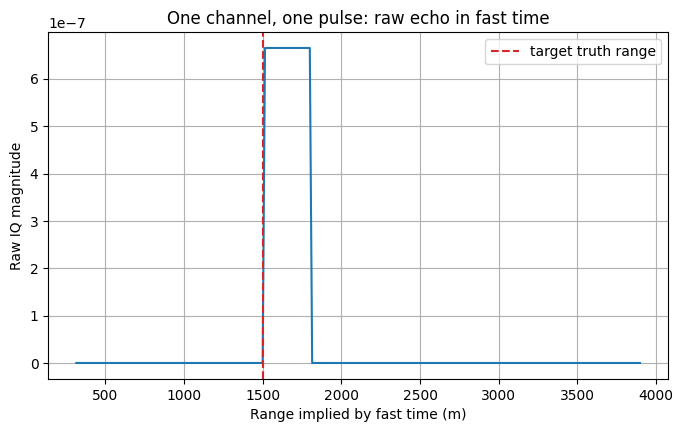

In [5]:
truth = raw.truth[0]
range_axis_m = raw.axes.fast_time_s * SPEED_OF_LIGHT / 2.0
target_delay_index = int(np.ceil(2.0 * truth.range_m * radar.waveform.sample_rate_hz / SPEED_OF_LIGHT))
lo = max(0, target_delay_index - 80)
hi = min(raw.iq.shape[-1], target_delay_index + 160)

fig, ax = plt.subplots()
ax.plot(range_axis_m[lo:hi], np.abs(raw.iq[0, 0, 0, lo:hi]))
ax.axvline(truth.range_m, color="tab:red", linestyle="--", label="target truth range")
ax.set_xlabel("Range implied by fast time (m)")
ax.set_ylabel("Raw IQ magnitude")
ax.set_title("One channel, one pulse: raw echo in fast time")
ax.legend();

### 3.3 Slow time: pulse-to-pulse phase -> Doppler

在同一个 range bin 上，沿 pulse index 观察相位。如果目标有 radial velocity，相位会随 pulse 旋转。当前 example target 的 radial velocity 是 0，所以这里应该接近一条平线。

如果把 YAML 里的 `radial_velocity_mps` 改成非零值，这张图会变成相位斜坡。

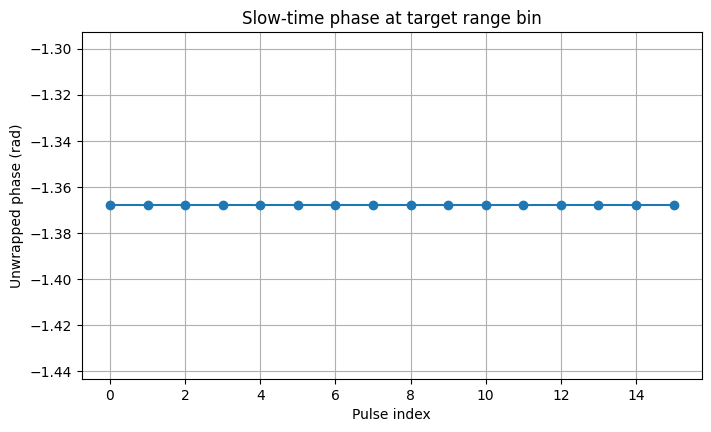

In [6]:
slow_time_signal = raw.iq[0, 0, :, target_delay_index]
slow_time_phase = np.unwrap(np.angle(slow_time_signal))

fig, ax = plt.subplots()
ax.plot(np.arange(len(slow_time_phase)), slow_time_phase, marker="o")
ax.set_xlabel("Pulse index")
ax.set_ylabel("Unwrapped phase (rad)")
ax.set_title("Slow-time phase at target range bin")
ax.grid(True);

### 3.4 Array space: phase pattern -> angle

同一个 pulse、同一个 range bin 上，把所有阵元的复数值拿出来，就是 array snapshot。

目标方向决定阵列上的 spatial phase pattern。当前 example target 在 boresight 附近，所以相位图接近平坦；如果目标 azimuth/elevation 偏离 boresight，会出现更明显的二维相位斜率。

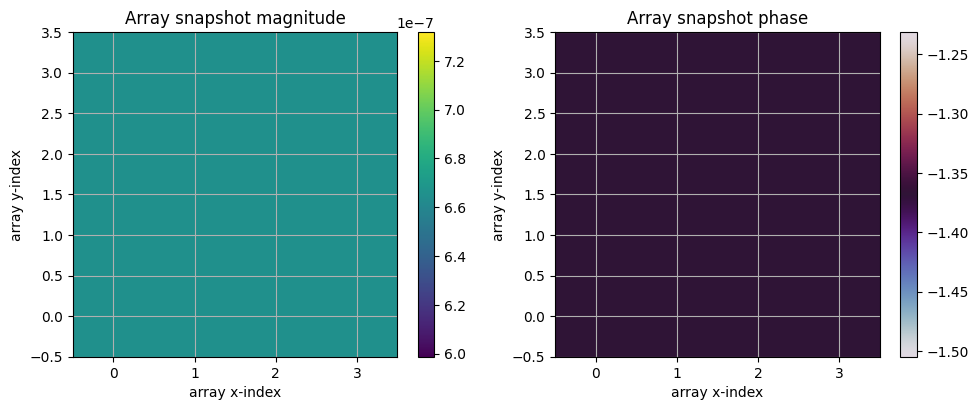

In [7]:
array_snapshot = raw.iq[:, :, 0, target_delay_index]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(np.abs(array_snapshot), origin="lower")
axes[0].set_title("Array snapshot magnitude")
axes[0].set_xlabel("array x-index")
axes[0].set_ylabel("array y-index")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(np.angle(array_snapshot), origin="lower", cmap="twilight")
axes[1].set_title("Array snapshot phase")
axes[1].set_xlabel("array x-index")
axes[1].set_ylabel("array y-index")
fig.colorbar(im1, ax=axes[1])
fig.tight_layout();

## 4. Process one dwell: IQ -> range-Doppler-angle cube

一个 dwell 的 processing chain 是：

```text
RawDwellData.iq
  -> range_compress()
  -> doppler_process()
  -> beamform_angle_grid()
  -> detect_radar_cube()
```

下面我们逐步看每一步的中间结果。

### 4.1 Range compression

Range compression 就是 fast time 上的 matched filtering：用发射 LFM waveform 的共轭反向版本做匹配滤波。

输出仍然保留 array 和 pulse 两个维度，但 fast-time 维度被解释为 range bins。

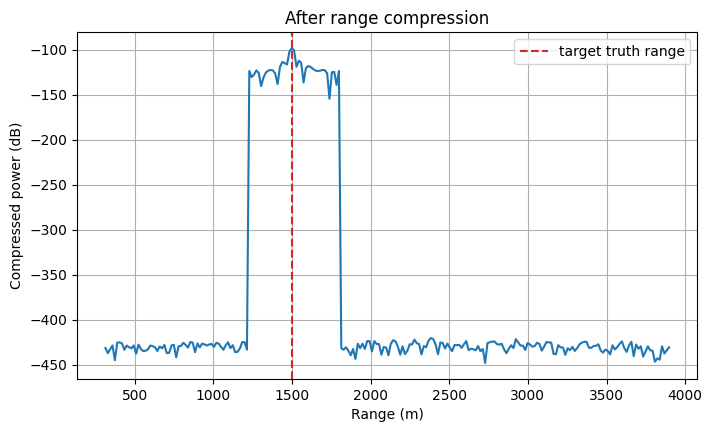

In [8]:
range_data = range_compress(raw, radar)
range_profile_power = np.max(np.abs(range_data[0, 0, :, :]) ** 2, axis=0)

fig, ax = plt.subplots()
ax.plot(range_axis_m[lo:hi], power_db(range_profile_power[lo:hi]))
ax.axvline(truth.range_m, color="tab:red", linestyle="--", label="target truth range")
ax.set_xlabel("Range (m)")
ax.set_ylabel("Compressed power (dB)")
ax.set_title("After range compression")
ax.legend();

### 4.2 Doppler processing

Doppler processing 沿 slow time / pulse index 做 FFT。

处理后，每个阵元都有一个 range-Doppler map。这里先看一个阵元的结果。

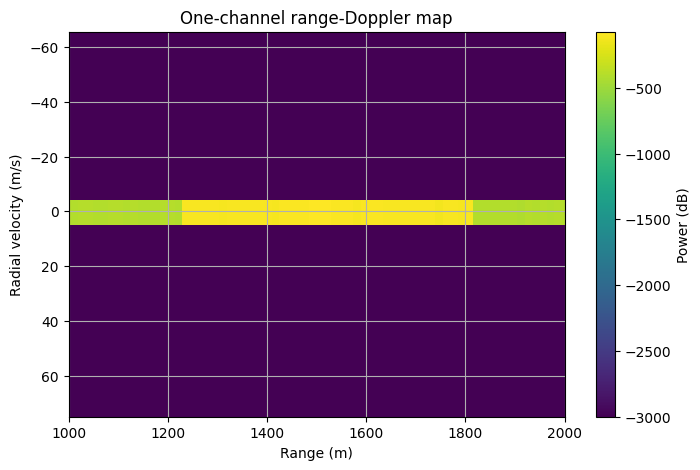

In [9]:
doppler_data, velocity_axis_mps = doppler_process(range_data, radar)
rd_power = np.abs(doppler_data[0, 0, :, :]) ** 2

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    power_db(rd_power).T,
    origin="lower",
    aspect="auto",
    extent=[range_axis_m[0], range_axis_m[-1], velocity_axis_mps[0], velocity_axis_mps[-1]],
)
ax.set_xlim(max(0, truth.range_m - 500), truth.range_m + 500)
ax.set_xlabel("Range (m)")
ax.set_ylabel("Radial velocity (m/s)")
ax.set_title("One-channel range-Doppler map")
fig.colorbar(im, ax=ax, label="Power (dB)");

### 4.3 Angle processing / beamforming

Angle processing 对每个 range-Doppler cell 拿到一个 array vector，然后对 angle grid 做 steering-vector projection。

当前代码使用 conventional digital beamforming：

$$
Y[R, f_D, u] = a^H(u) Z[:, R, f_D]
$$

下面找到 cube 里的最大 cell，然后画这个 cell 上的 azimuth/elevation response。

peak range: 1499.0 m
peak radial velocity: -0.00 m/s


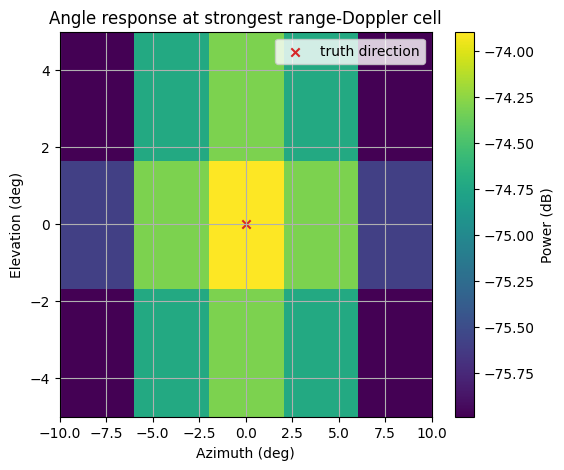

In [10]:
cube = beamform_angle_grid(
    doppler_data,
    radar,
    config.processing.angle_grid_az_deg,
    config.processing.angle_grid_el_deg,
)
cube_power = np.abs(cube) ** 2
peak_index = np.unravel_index(np.argmax(cube_power), cube_power.shape)
peak_range_index, peak_doppler_index, _, _ = peak_index
angle_power = cube_power[peak_range_index, peak_doppler_index, :, :]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    power_db(angle_power).T,
    origin="lower",
    aspect="auto",
    extent=[
        min(config.processing.angle_grid_az_deg),
        max(config.processing.angle_grid_az_deg),
        min(config.processing.angle_grid_el_deg),
        max(config.processing.angle_grid_el_deg),
    ],
)
ax.scatter([truth.az_deg], [truth.el_deg], marker="x", color="tab:red", label="truth direction")
ax.set_xlabel("Azimuth (deg)")
ax.set_ylabel("Elevation (deg)")
ax.set_title("Angle response at strongest range-Doppler cell")
ax.legend()
fig.colorbar(im, ax=ax, label="Power (dB)");

print(f"peak range: {range_axis_m[peak_range_index]:.1f} m")
print(f"peak radial velocity: {velocity_axis_mps[peak_doppler_index]:.2f} m/s")

### 4.4 Full dwell processing and detections

`process_dwell()` 把上面三步串起来，并运行 detector。

Detection 不是 confirmed target，只是当前 dwell 的 processed cube 里一个足够强的局部峰值。

In [11]:
processed = process_dwell(raw, radar, config.processing)

print(f"radar cube shape: {processed.radar_cube.data.shape}")
print("expected axes: (range, doppler, azimuth, elevation)")
display(Markdown(detection_table(processed.detections)))

radar cube shape: (1000, 16, 5, 3)
expected axes: (range, doppler, azimuth, elevation)


| dwell | range (m) | radial velocity (m/s) | az (deg) | el (deg) | SNR (dB) |
| ---: | ---: | ---: | ---: | ---: | ---: |
| 0 | 1499.0 | -0.00 | 0.0 | 0.0 | 333.6 |

## 5. Full scan: 多个 dwell 如何形成 air picture？

扫描整个空域不是一次性得到一个瞬时全空域 cube，而是在时间上执行多个 dwell：

```text
beam 0 -> dwell 0 -> detections
beam 1 -> dwell 1 -> detections
beam 2 -> dwell 2 -> detections
...
all detections -> tracker -> tracks
```

当前 V1 用固定二维 scan schedule，不做 search-confirm-track 的闭环资源管理。

In [12]:
result = run_experiment(CONFIG_PATH)
all_detections = tuple(d for dwell in result.processed_dwells for d in dwell.detections)

print(f"num dwell tasks: {len(result.tasks)}")
print(f"num processed dwells: {len(result.processed_dwells)}")
print(f"num detections: {len(all_detections)}")
print(f"num tracks: {len(result.tracks)}")

num dwell tasks: 18
num processed dwells: 18
num detections: 18
num tracks: 1


### 5.1 Scan schedule: beam positions

每个点是一个 dwell 的 look direction。颜色 / annotation 对应 dwell id。

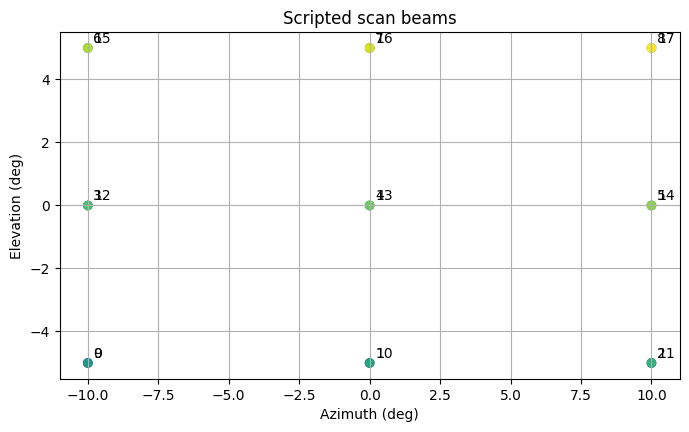

In [13]:
plot_scan_beams(result.tasks);

### 5.2 Per-dwell detections

每个 dwell 都独立产生一批 detections。tracker 后续把这些带时间戳的 detections 串起来。

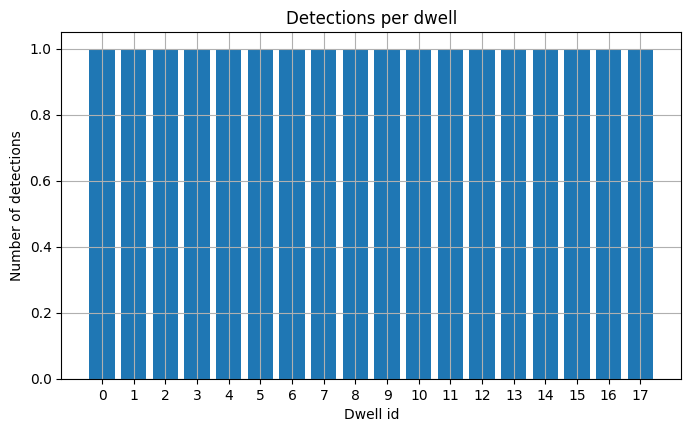

In [14]:
dwell_ids = [dwell.task.id for dwell in result.processed_dwells]
detection_counts = [len(dwell.detections) for dwell in result.processed_dwells]

fig, ax = plt.subplots()
ax.bar(dwell_ids, detection_counts)
ax.set_xlabel("Dwell id")
ax.set_ylabel("Number of detections")
ax.set_title("Detections per dwell")
ax.set_xticks(dwell_ids);

### 5.3 One dwell display: range-Doppler map

这是 display 层视角：对某个 dwell 的 processed result 画 range-Doppler map。

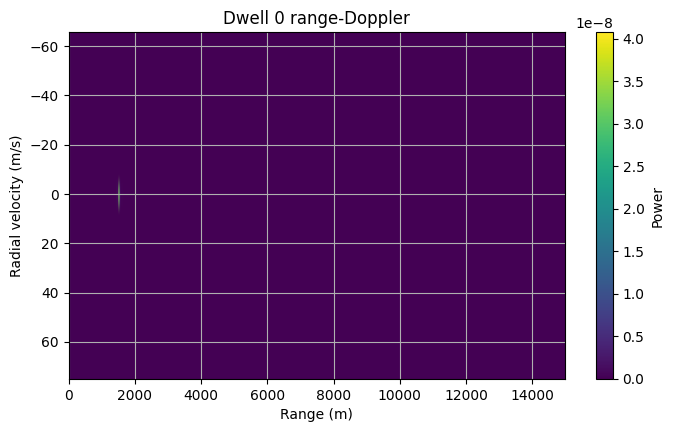

In [15]:
plot_range_doppler(result.processed_dwells[0]);

### 5.4 Global air picture: detections and tracks

把所有 dwell 的 detections 放到统一坐标解释下，就得到 display-level 的 air picture。

Track 是多次 detections 经过 association 和 filtering 后形成的持续目标状态。

| id | status | x (m) | y (m) | z (m) | vx (m/s) | vy (m/s) | vz (m/s) |
| ---: | --- | ---: | ---: | ---: | ---: | ---: | ---: |
| 1 | confirmed | 1499.0 | 0.0 | 0.0 | 0.00 | 0.00 | 0.00 |

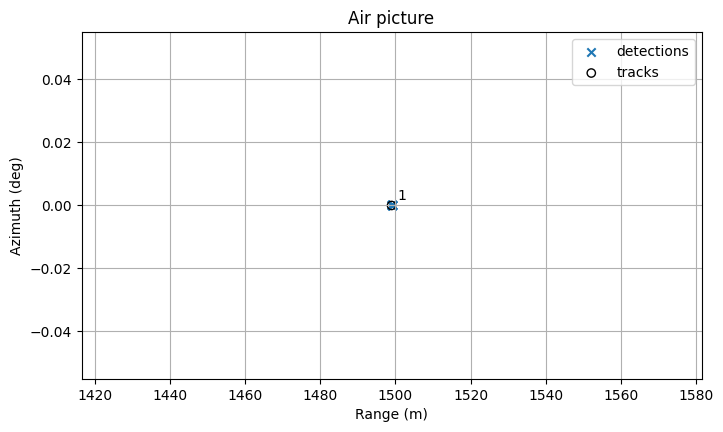

In [16]:
plot_air_picture(all_detections, result.tracks);
display(Markdown(track_table(result.tracks)))

## 6. Recap

这个 tutorial 里，我们把 mental model 和代码一一对应起来：

| Mental model | Code / data |
| --- | --- |
| 一次看一个方向 | `DwellTask` |
| 扫描空域 | `ScriptedScanScheduler` / `run_experiment()` |
| 原始多通道复数数据 | `RawDwellData.iq` |
| fast time delay -> range | `range_compress()` |
| slow time phase rotation -> velocity | `doppler_process()` |
| array phase slope -> angle | `beamform_angle_grid()` |
| cube 中的峰值 | `Detection` |
| 多次 detections 的状态估计 | `Track` |

最重要的一句话：

> 相控阵 PD 雷达每次 dwell 用一个发射波束照亮一个有限角域，接收阵列采集多通道 IQ。目标在 IQ 中表现为 fast-time delay、slow-time Doppler phase rotation 和 array-space phase slope。处理链沿这三个维度做匹配投影，得到 range、velocity、angle；detector 把 cube peak 变成 detection；tracker 把多次 detections 变成 track。